targets: ['malignant' 'benign']
features used: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
shape after PCA: (569, 3)


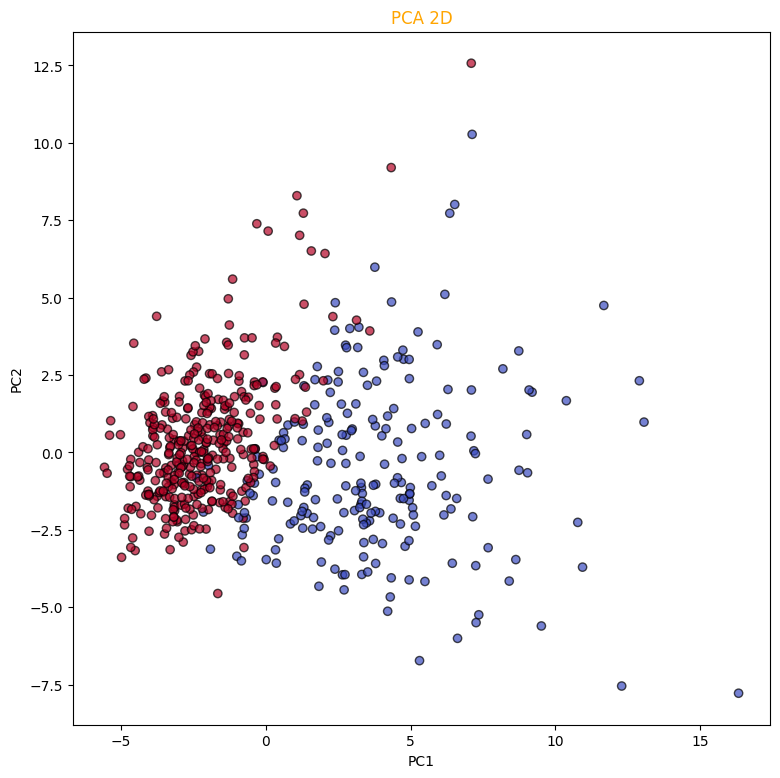

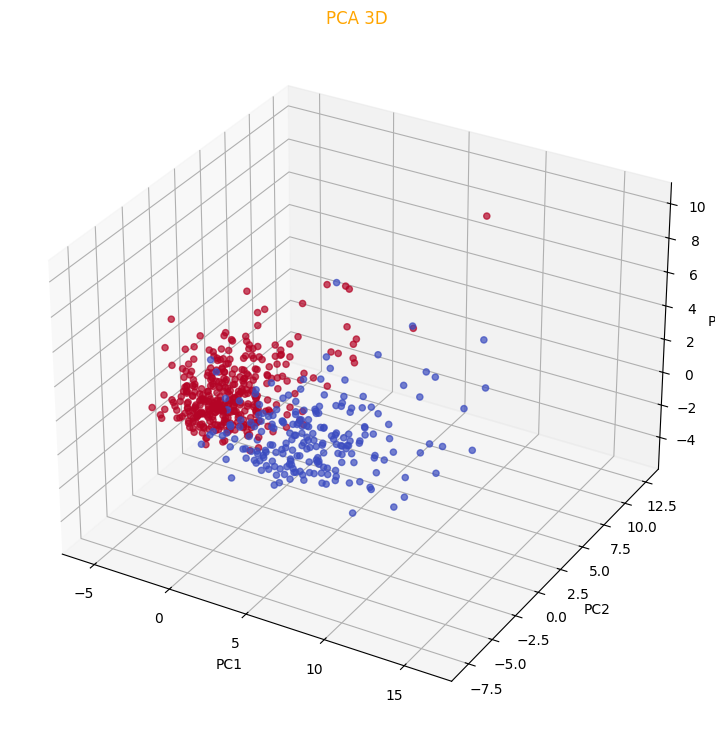

variance ratio: [0.44272026 0.18971182 0.09393163]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# load dataset
data = load_breast_cancer()

print("targets:", data.target_names)
features = data.feature_names.tolist()
print("features used:", features)

# scale
X = data.data
sc = StandardScaler()
scaled_X = sc.fit_transform(X)

# pca
pca = PCA(n_components=3, random_state=7)
pca.fit(scaled_X)
X_pca = pca.transform(scaled_X)

print("shape after PCA:", X_pca.shape)

# 2D scatter (different colormap + labels)
plt.figure(figsize=(9, 9))
plt.title('PCA 2D', color="orange")
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=data.target,
            cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# 3D scatter
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=data.target,
           cmap='coolwarm', alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA 3D', color="orange")
plt.show()

print("variance ratio:", pca.explained_variance_ratio_)